# 03 — Inductor Selection

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Size the buck-boost inductor: required L for ≈30% ripple across the input range, saturation-current check, then an efficiency / loss-breakdown sweep over the candidate part database (data/inductors.csv).

**Design basis (V1):** loss/efficiency optimization is done at **5 V / 3 A input (15 W)** — the common output profile of non-PD USB battery banks and USB Type-C Current @ 3 A. It is also the worst-case source: lowest input voltage, highest boost ratio, and input-power limited, so every mW of converter loss directly reduces the fan power available. Higher PD voltages (9/15/20 V) are checked for ripple, I_sat and 42 W peak capability, not optimized. In boost mode the average inductor current equals the input current, so this point is fixed at I_L = 3 A regardless of efficiency.

**Key result / decision:** **47 µH, Würth 7443634700** (the V1 board part) — meets the ripple target at all operating points with I_sat margin, and is the only part with manufacturer loss data that JLCPCB stocks ($6.70; hand check 2026-09-14). Three 33 µH parts have lower calculated loss at 15 W input — η 98.78–99.10 % vs **98.54 %**, best Coilcraft AGP2923-333KL — but none is stocked at JLCPCB (> $10 each). What they would buy is small: 37–84 mW more fan power, at most $0.15/yr of electricity, and more board area. They are recorded as V2 candidates (see Final Conclusions).

**See also:** 01 (power budget), 04 (MOSFET selection), data/inductors.csv (part database), data/inductor_losses_measured.csv (manufacturer-calculator AC/DC loss data at the 5 V / 3 A point: Würth REDEXPERT, Coilcraft Power Inductor Finder).

## Operating envelope and design parameters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import the central truth namespaces from constants.py
import sys; sys.path.insert(0, '..')   # repo root: constants.py, data/
from constants import USB, FAN, TOTAL_MAX_LOAD_WATTS, make_design
DESIGN = make_design(load_parts=True, ind_csv='../data/inductors.csv', fet_csv='../data/mosfets.csv')
i_in_nom_max = USB.I_MAX_STANDARD   # 3 A common USB-C limit

# --- Input Power Points (USB-C PD) ---
# Use ranges and tolerances defined in USBCSpecs
v_in = np.linspace(USB.V_MIN * (1 - USB.V_TOLERANCE), 
                   USB.V_MAX * (1 + USB.V_TOLERANCE), 100)

# --- Output Parameters ---
v_out = FAN.V_NOMINAL
# Use the pre-calculated total load (Fans + System Logic) from constants.py
max_load_watts = TOTAL_MAX_LOAD_WATTS

print(f"Max System Load (Fans + Logic): {max_load_watts:.2f}W")

Max System Load (Fans + Logic): 42.73W


Design goals: maximize efficiency when using a low-power USB battery bank; fit inside a PC-fan air-purifier case with minimal space concerns.

## Required inductance and saturation check

Required L per operating point (buck and boost formulas) and validation of the selected part.

In [2]:
import numpy as np
import constants as cfg

# --- Configuration ---
# Operating points from your USB-C range
v_in_points = np.array([4.5, 9, 11.5, 15, 22.5])
target_v_out = cfg.FAN.V_NOMINAL
ripple_ratio = 0.3  # Target 30% inductor current ripple

# Use the derived max load from our constants
i_out_max = cfg.TOTAL_MAX_LOAD_WATTS / target_v_out

l_required_values = []

print(f"--- Inductor Requirement Analysis ---")
print(f"Target V_out: {target_v_out}V | Max Load: {i_out_max:.2f}A\n")

for v_in in v_in_points:
    # 1. Calculate Target Ripple (Delta I_L)
    delta_i_target = ripple_ratio * i_out_max
    
    # 2. Calculate required L for this specific V_in
    if v_in > target_v_out:
        # Buck Mode
        l_calc = (target_v_out * (v_in - target_v_out)) / (delta_i_target * cfg.DESIGN.F_SW_HZ * v_in)
    else:
        # Boost Mode
        # Note: In boost, ripple is highest at low V_in
        duty_cycle = 1 - (v_in / target_v_out)
        l_calc = (v_in * duty_cycle) / (delta_i_target * cfg.DESIGN.F_SW_HZ)
    
    l_required_values.append(abs(l_calc))
    
    mode = "BUCK " if v_in > target_v_out else "BOOST"
    print(f"V_in: {v_in:>4}V | Mode: {mode} | Req. L: {l_calc*1e6:>6.2f} µH")

# --- Validation against Selected Component ---
max_req_l = max(l_required_values)
actual_l = DESIGN.INDUCTOR.L

# Peak Current Check (I_peak = I_out_avg + Delta_I/2)
# Using worst-case ripple for the selected 47uH inductor
worst_case_delta_i = (target_v_out * (max(v_in_points) - target_v_out)) / (actual_l * cfg.DESIGN.F_SW_HZ * max(v_in_points))
i_peak = i_out_max + (worst_case_delta_i / 2)

print(f"\n--- Final Design Check ---")
print(f"Max Inductance Required: {max_req_l*1e6:.2f} µH")
print(f"Selected Inductor L:     {actual_l*1e6:.2f} µH")

if actual_l >= max_req_l:
    print(f"STATUS: PASS (L value is sufficient for {ripple_ratio*100}% ripple)")
else:
    print(f"STATUS: WARNING (Ripple will be higher than {ripple_ratio*100}%)")

print(f"Calculated Peak Current: {i_peak:.2f} A")
print(f"Inductor I_sat Rating:   {DESIGN.INDUCTOR.I_SAT:.2f} A")

if i_peak < DESIGN.INDUCTOR.I_SAT:
    print("STATUS: PASS (Inductor will not saturate at max load)")
else:
    print("STATUS: FAIL (Peak current exceeds I_sat! Core saturation likely)")

--- Inductor Requirement Analysis ---
Target V_out: 12.0V | Max Load: 3.56A

V_in:  4.5V | Mode: BOOST | Req. L:  26.33 µH
V_in:  9.0V | Mode: BOOST | Req. L:  21.06 µH
V_in: 11.5V | Mode: BOOST | Req. L:   4.49 µH
V_in: 15.0V | Mode: BUCK  | Req. L:  22.47 µH
V_in: 22.5V | Mode: BUCK  | Req. L:  52.42 µH

--- Final Design Check ---
Max Inductance Required: 52.42 µH
Selected Inductor L:     47.00 µH
STATUS: WARNING (Ripple will be higher than 30.0%)
Calculated Peak Current: 4.16 A
Inductor I_sat Rating:   7.50 A
STATUS: PASS (Inductor will not saturate at max load)


## Verification of the chosen part

In [3]:
import constants as cfg

# 1. Back-calculate actual ripple using the CHOSEN inductor
# Formula: Delta_I = (Vout * (Vin - Vout)) / (L_actual * Fsw * Vin)
v_in_max = cfg.USB.V_MAX
actual_l = DESIGN.INDUCTOR.L

# Calculate worst-case ripple (usually occurs at highest Vin in Buck mode)
actual_delta_i = (cfg.FAN.V_NOMINAL * (v_in_max - cfg.FAN.V_NOMINAL)) / \
                 (actual_l * cfg.DESIGN.F_SW_HZ * v_in_max)

# 2. Calculate Ripple Percentage relative to Max Load
actual_ripple_ratio = (actual_delta_i / (cfg.TOTAL_MAX_LOAD_WATTS / cfg.FAN.V_NOMINAL)) * 100

print(f"--- Inductor Selection Verification ---")
print(f"Chosen Part: {DESIGN.INDUCTOR.PART_NUMBER}")
print(f"Actual Inductance: {actual_l*1e6:.1f} µH")
print(f"Resulting Peak-to-Peak Ripple: {actual_delta_i:.3f} A")
print(f"Actual Ripple Ratio: {actual_ripple_ratio:.1f} %")

# 3. Safety Check
if actual_ripple_ratio > 40:
    print("WARNING: Ripple exceeds 40%. Consider a larger Inductor or higher F_sw.")
elif actual_ripple_ratio < 20:
    print("NOTE: Ripple is very low. You might be able to use a physically smaller inductor.")
else:
    print("STATUS: Ripple ratio is within the optimal 20-40% design window.")

--- Inductor Selection Verification ---
Chosen Part: 7443634700
Actual Inductance: 47.0 µH
Resulting Peak-to-Peak Ripple: 1.021 A
Actual Ripple Ratio: 28.7 %
STATUS: Ripple ratio is within the optimal 20-40% design window.


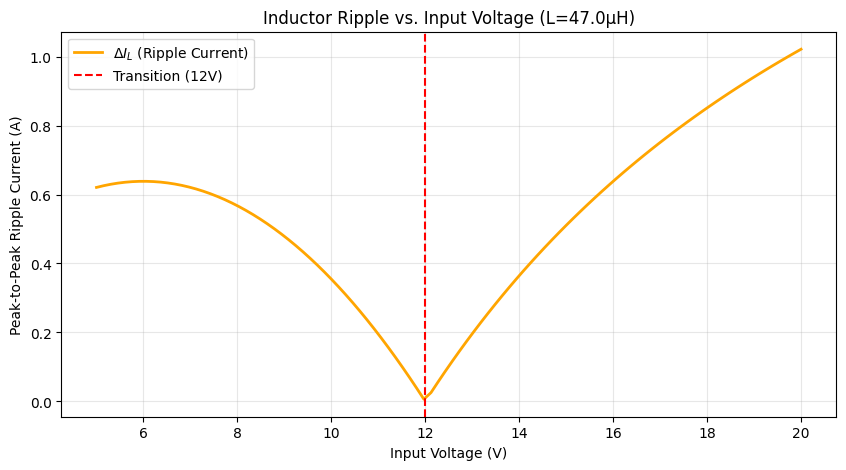

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import constants as cfg

# Generate a range of USB-C input voltages
v_in_range = np.linspace(cfg.USB.V_MIN, cfg.USB.V_MAX, 100)
v_out = cfg.FAN.V_NOMINAL
L = DESIGN.INDUCTOR.L
f_sw = cfg.DESIGN.F_SW_HZ

def calculate_ripple(vin, vout, l_val, freq):
    if vin > vout: # Buck
        return (vout * (vin - vout)) / (l_val * freq * vin)
    else: # Boost
        duty_cycle = 1 - (vin / vout)
        return (vin * duty_cycle) / (l_val * freq)

ripples = [calculate_ripple(v, v_out, L, f_sw) for v in v_in_range]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(v_in_range, ripples, label=r'$\Delta I_L$ (Ripple Current)', color='orange', lw=2)
plt.axvline(x=v_out, color='red', linestyle='--', label='Transition (12V)')

# Formatting
plt.title(f"Inductor Ripple vs. Input Voltage (L={L*1e6:.1f}µH)")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Peak-to-Peak Ripple Current (A)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## LM5176 gate-driver parameters (used by the loss model)

In [5]:
# Gate Driver
v_gate_drive = 7.35
i_gate_drive_source = 1.8
i_gate_drive_sink = 2.2  
r_h_driver_source_pullup = 1.8
r_h_driver_source_pulldown = 1.1
r_l_driver_source_pullup = 1.7
r_l_driver_source_pulldown = 1.3
t_DT1 = 45e-9
r_gate_ext = 0.0      # External resistor
i_Q_nom = 2e-3 #V_in operating current, VEN/UVLO = 2 V, VFB = 0.9 V
i_Q_max =  4e-3

## Candidate sweep: efficiency and loss breakdown

Sweeps the inductor database against the best MOSFET; grouped by family/footprint.

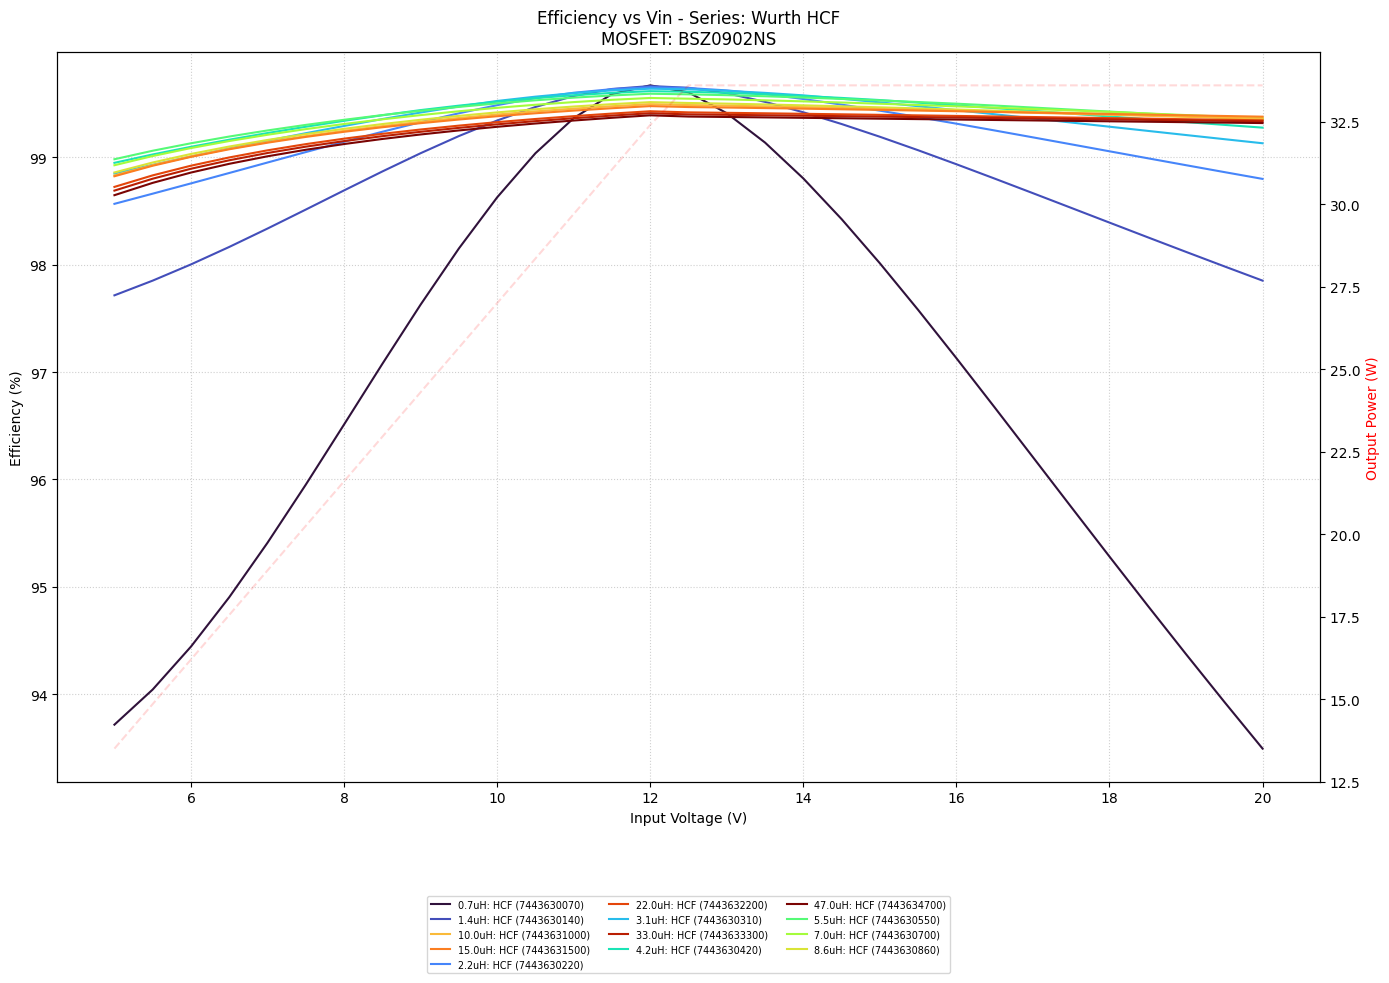

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('../data/inductors.csv')
mos_df = pd.read_csv('../data/mosfets.csv').rename(columns={'Part_Number': 'Part Number'})

# --- ADVANCED FILTER CONFIGURATION ---
# We use bitwise OR (|) to combine different selection criteria
# 1. Any series containing 'ERU 24'
# 2. Any series 'HCF' specifically in size '2815'

mask = (
    #(ind_df['Series'].str.contains('ERU 24', case=False, na=False)) #| 
    ((ind_df['Series'] == 'HCF') & (ind_df['Size_Code'].astype(str) == '2013'))
)

ind_df = ind_df[mask]

if ind_df.empty:
    print("No parts found matching the criteria! Check CSV naming.")
# -------------------------------------

# Use best MOSFET
best_mos_name = 'BSZ0902NS'
best_mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

def calc_efficiency_forced_ccm(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q):
    if p_out <= 0: p_out = 1e-6
    i_out = p_out / v_out
    
    # Logic for Buck vs Boost
    if v_in > v_out: # Buck
        d = v_out / v_in
        i_l_avg = i_out
        delta_il = (v_in - v_out) * d / (L * f_sw)
        v_sw_node = v_in
    else: # Boost
        d = 1 - (v_in / v_out)
        i_l_avg = i_out / (1 - d)
        delta_il = (v_in * d) / (L * f_sw)
        v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    p_dcr = i_l_rms**2 * dcr
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    total_loss = p_dcr + p_cond + p_sw + p_gate + p_ic
    return (p_out / (p_out + total_loss)) * 100

# Params
v_in_points = np.linspace(5, 20, 31)
v_out, f_sw, v_gate, i_gate_src, i_gate_snk, i_q = 12, 100e3, 7.35, 1.8, 2.2, 2e-3
max_load_watts, i_in_limit, est_eff = 33.6, 3.0, 0.9
actual_p_out = [min(max_load_watts, v * i_in_limit * est_eff) for v in v_in_points]

rdson = (best_mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(best_mos['RDSon_10V_Typ(mOhm)']) else best_mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (best_mos['Qg_10V_Typ(nC)'] if not pd.isna(best_mos['Qg_10V_Typ(nC)']) else best_mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = best_mos['Qgd_Typ(nC)']*1e-9

# Plotting setup
unique_l = sorted(ind_df['Inductance_uH'].unique())
colors = plt.cm.turbo(np.linspace(0, 1, len(unique_l))) # Using turbo for better contrast
l_color_map = dict(zip(unique_l, colors))
line_styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]

fig, ax1 = plt.subplots(figsize=(14, 10))
ax2 = ax1.twinx()

for l_val in unique_l:
    subset = ind_df[ind_df['Inductance_uH'] == l_val]
    color = l_color_map[l_val]
    for idx, (_, ind) in enumerate(subset.iterrows()):
        ls = line_styles[idx % len(line_styles)]
        eff_list = [calc_efficiency_forced_ccm(v, v_out, p, ind['Inductance_uH']*1e-6, ind['DCR_max_mOhm']*1e-3, 
                                               rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q) 
                    for v, p in zip(v_in_points, actual_p_out)]
        
        # Label includes Series and Size for clarity when filtered
        label_text = f"{l_val}uH: {ind['Series']} ({ind['Part_Number']})"
        ax1.plot(v_in_points, eff_list, color=color, linestyle=ls, label=label_text)

ax1.set_xlabel('Input Voltage (V)')
ax1.set_ylabel('Efficiency (%)')
ax2.set_ylabel('Output Power (W)', color='red')
ax2.plot(v_in_points, actual_p_out, color='red', alpha=0.15, linestyle='--', label='Power Envelope')

# Legend and Title
handles, labels = ax1.get_legend_handles_labels()
sorted_indices = np.argsort(labels)
ax1.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='x-small')

# Dynamically update title based on filters
filter_desc = f"Series: {'Wurth HCF'}"
ax1.set_title(f"Efficiency vs Vin - {filter_desc}\nMOSFET: {best_mos_name}")
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 5 V / 3 A input point: loss breakdown with P_in fixed at 15 W

The cells below fix the **input** at the design-basis point, V_in = 5 V × I_in = 3 A = **15 W**, instead of assuming an output power. The USB source is the limit at this corner, so the output is whatever the losses leave: P_out = P_in − P_loss, η = P_out / P_in. In boost mode I_L,avg = I_in = 3 A, and ripple depends only on V_in, V_out, L and f_sw, so every modeled loss term is set by the input point alone — no efficiency guess and no iteration. (Earlier versions of these cells assumed P_out = 0.9 × 15 = 13.5 W, which implied I_L = 2.7 A and did not match the 3 A calculator runs.)

Duty is the ideal D = 1 − V_in/V_out = 58.3 %, the value entered in the calculators. The real duty is slightly higher to supply the losses; that correction is not modeled.

Inductor loss comes from two sources, kept side by side:

| Series | Inductor DC loss | Inductor AC loss | Kind of source | Coverage |
|---|---|---|---|---|
| **Rp model** | I_L,rms² × `DCR_max_mOhm` | V_L,rms² / `Rp_Ohm` (parallel resistance from the SPICE model) | calculated, approximate | parts in `data/inductors.csv` with a SPICE Rp (AC term is 0 where there is none) |
| **Manufacturer calculator** | `P_dc_mW` | `P_ac_mW` | manufacturer loss-calculator output, entered by hand: Würth REDEXPERT, Coilcraft Power Inductor Finder | rows with results in `data/inductor_losses_measured.csv` |

Both calculators report P_dc as I_L,avg² × typical DCR (checked below), so their AC figure holds core loss plus the ripple's winding loss. Comparing parts across the two tools assumes their loss models are comparably accurate; that has not been checked against a measurement.

All other terms — MOSFET conduction, switching, gate drive, controller I_Q — use the same calculation in both series, with the V1 FET (**BSC0902NS**, `constants.ACTIVE_FET_ID`) and the LM5176 driver parameters above. (Earlier versions of these cells used BSZ0501NSI or BSZ0902NS; the ranking check below covers all three.) Not modeled: current-sense resistor, capacitor ESR, dead-time body-diode conduction, PCB copper. The efficiencies here are calculated values for ranking inductors, not a prediction of measured board efficiency.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import constants as cfg

# --- Operating point: source-limited 5 V / 3 A input, boost ---
v_in_5v = cfg.USB.V_MIN               # 5 V
i_in_5v = cfg.USB.I_MAX_STANDARD      # 3 A
p_in_5v = v_in_5v * i_in_5v           # 15 W, set by the source
v_out = cfg.FAN.V_NOMINAL             # 12 V
f_sw = cfg.DESIGN.F_SW_HZ             # 100 kHz

# --- Part data ---
ind_db = pd.read_csv('../data/inductors.csv', dtype={'Part_Number': str})
mos_df = pd.read_csv('../data/mosfets.csv')
calc_df = pd.read_csv('../data/inductor_losses_measured.csv', dtype={'Part_Number': str})
calc_df = calc_df.dropna(subset=['P_total_mW'])   # only rows with calculator output entered

# Which manufacturer tool produced each row
CALC_TOOL = {'Wurth Elektronik': 'REDEXPERT', 'Coilcraft': 'Coilcraft PIF'}   # PIF = Power Inductor Finder
calc_df['Tool'] = calc_df['Manufacturer'].map(CALC_TOOL).fillna(calc_df['Manufacturer'])
assert calc_df['Part_Number'].isin(ind_db['Part_Number']).all(), \
    f"loss rows not in inductors.csv: {sorted(set(calc_df['Part_Number']) - set(ind_db['Part_Number']))}"

def fet_params(name):
    """R_DS(on) and Q_g at 10 V where listed (LM5176 drive is 7.35 V), else 4.5 V; plus Q_gd."""
    m = mos_df[mos_df['Part_Number'] == name].iloc[0]
    rdson = (m['RDSon_10V_Typ(mOhm)'] if not pd.isna(m['RDSon_10V_Typ(mOhm)']) else m['RDSon_4.5V_Typ(mOhm)'])*1e-3
    qg = (m['Qg_10V_Typ(nC)'] if not pd.isna(m['Qg_10V_Typ(nC)']) else m['Qg_4.5V_Typ(nC)'])*1e-9
    qgd = m['Qgd_Typ(nC)']*1e-9
    return rdson, qg, qgd

fet_name = cfg.ACTIVE_FET_ID          # V1 board part
fet_v1 = fet_params(fet_name)

LOSS_TERMS = ['Inductor DC Loss', 'Inductor AC Loss', 'MOSFET Conduction',
              'Switching Loss', 'Gate Drive Loss', 'Controller IQ Loss']
# Categorical slots in fixed order (CVD-validated for adjacent segments)
LOSS_COLORS = dict(zip(LOSS_TERMS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']))

def boost_loss_breakdown(v_in, i_in, v_out, L, dcr, rp, f_sw, fet=fet_v1):
    """Boost-mode losses (W) with the INPUT fixed: I_L,avg = I_in, so no efficiency guess is needed.
    Inductor terms are the Rp model; calc_breakdown() swaps in manufacturer-calculator values."""
    rdson, qg, qgd = fet
    d = 1 - (v_in / v_out)            # ideal duty, as entered in the calculators
    i_l_avg = i_in
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out

    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)

    # Inductor AC/core loss from the SPICE-model parallel resistor: P_ac = V_L,rms^2 / Rp
    if rp and not pd.isna(rp) and rp > 0:
        p_ac = ((v_in**2 * d) + ((v_in - v_out)**2 * (1 - d))) / rp
    else:
        p_ac = 0.0

    t_rise, t_fall = qgd / i_gate_drive_source, qgd / i_gate_drive_sink
    return dict(zip(LOSS_TERMS, [
        i_l_rms**2 * dcr,
        p_ac,
        i_l_rms**2 * (rdson * 2),
        0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise),
        2 * qg * v_gate_drive * f_sw,
        v_in * i_Q_nom,
    ]))

def rp_model_breakdown(calc_row, fet=fet_v1):
    """Rp-model breakdown at a calculator row's operating point (Vin, Iin, Vout, fsw)."""
    part = ind_db[ind_db['Part_Number'] == calc_row['Part_Number']].iloc[0]
    return boost_loss_breakdown(calc_row['Vin_V'], calc_row['Iin_A'], calc_row['Vout_V'], part['Inductance_uH']*1e-6,
                                part['DCR_max_mOhm']*1e-3, part['Rp_Ohm'], calc_row['Freq_kHz']*1e3, fet)

def calc_breakdown(calc_row, fet=fet_v1):
    """Same operating point, with the inductor terms replaced by the calculator's P_dc / P_ac."""
    res = rp_model_breakdown(calc_row, fet)
    res['Inductor DC Loss'] = calc_row['P_dc_mW'] * 1e-3
    res['Inductor AC Loss'] = calc_row['P_ac_mW'] * 1e-3
    return res

# What the calculators' P_dc contains: P_dc / I_avg^2 reproduces the typical DCR (DCR_typ_mOhm, or the
# SPICE-model series resistance Rs_spice_Ohm where no typical is listed), i.e. DC current only at typical
# DCR. The ripple's winding loss is therefore inside P_ac. The Rp model instead uses I_rms^2 x DCR_max.
chk = calc_df.drop_duplicates('Part_Number').merge(
    ind_db[['Part_Number', 'DCR_typ_mOhm', 'Rs_spice_Ohm', 'DCR_max_mOhm']], on='Part_Number')
chk['R_from_P_dc_mOhm'] = chk['P_dc_mW'] / chk['I_avg_A']**2
chk['Rs_spice_mOhm'] = chk['Rs_spice_Ohm'] * 1e3
print(f"Operating point: Vin = {v_in_5v:.0f} V, Iin = {i_in_5v:.0f} A, Pin = {p_in_5v:.0f} W, Vout = {v_out:.0f} V | MOSFET: {fet_name}")
print(f"Calculator rows with results: {len(calc_df)} ({calc_df['Tool'].value_counts().to_dict()})\n")
print("Calculator P_dc / I_avg^2 vs model resistances:")
print(chk[['Part_Number', 'Tool', 'Size_Code', 'R_from_P_dc_mOhm', 'DCR_typ_mOhm', 'Rs_spice_mOhm', 'DCR_max_mOhm']]
      .round(2).to_string(index=False))

Operating point: Vin = 5 V, Iin = 3 A, Pin = 15 W, Vout = 12 V | MOSFET: BSC0902NS
Calculator rows with results: 18 ({'REDEXPERT': 17, 'Coilcraft PIF': 1})

Calculator P_dc / I_avg^2 vs model resistances:
   Part_Number          Tool      Size_Code  R_from_P_dc_mOhm  DCR_typ_mOhm  Rs_spice_mOhm  DCR_max_mOhm
    7443632200     REDEXPERT           2013             10.64           NaN          10.65         11.72
    7443633300     REDEXPERT           2013             11.44           NaN          11.40         12.54
    7443634700     REDEXPERT           2013             12.22           NaN          12.20         13.42
   74436413300     REDEXPERT           2815              1.33           NaN           1.33          1.44
    7443643300     REDEXPERT           2818              2.40           NaN           2.40          2.64
74437429203330     REDEXPERT 2920 litz wire             15.33           NaN          15.30         16.83
74437429203470     REDEXPERT 2920 litz wire             19.3

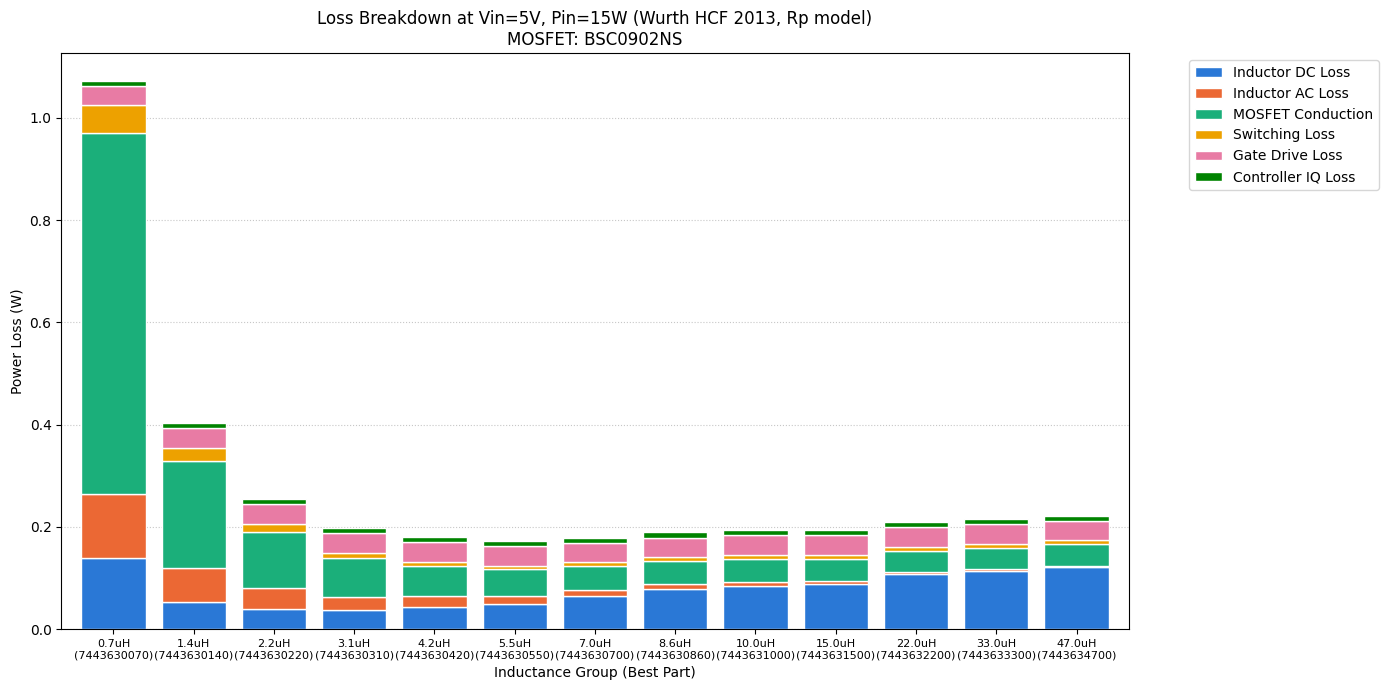

                     Inductor DC (mW)  Inductor AC (mW)  MOSFET Conduction (mW)  Switching (mW)  Gate Drive (mW)  Controller IQ (mW)  Total (mW)  P_out (W)  Eff (%)
0.7uH (7443630070)             139.85            124.59                  706.91           53.51            38.22                10.0     1073.07      13.93    92.85
1.4uH (7443630140)              53.75             66.58                  207.78           26.36            38.22                10.0      402.69      14.60    97.32
2.2uH (7443630220)              39.02             42.16                  108.78           16.49            38.22                10.0      254.67      14.75    98.30
3.1uH (7443630310)              37.67             25.38                   75.33           11.48            38.22                10.0      198.08      14.80    98.68
4.2uH (7443630420)              43.48             20.48                   59.89            8.27            38.22                10.0      180.34      14.82    98.80
5.5uH (744

In [8]:
# --- Rp model: Würth HCF 2013, every inductance value (lowest-DCR part per value) ---
sub_df = ind_db[ind_db['Size_Code'].astype(str) == '2013']

unique_l = sorted(sub_df['Inductance_uH'].unique())
breakdowns = []
labels = []

for l_val in unique_l:
    subset = sub_df[sub_df['Inductance_uH'] == l_val]
    best_ind = subset.loc[subset['DCR_max_mOhm'].idxmin()]

    res = boost_loss_breakdown(v_in_5v, i_in_5v, v_out, best_ind['Inductance_uH']*1e-6, best_ind['DCR_max_mOhm']*1e-3,
                               best_ind['Rp_Ohm'], f_sw)
    breakdowns.append(res)
    labels.append(f"{l_val}uH\n({best_ind['Part_Number']})")

df_breakdown = pd.DataFrame(breakdowns, index=labels)

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
df_breakdown.plot(kind='bar', stacked=True, ax=ax, width=0.8, edgecolor='white', linewidth=1,
                  color=[LOSS_COLORS[t] for t in df_breakdown.columns])

ax.set_title(f"Loss Breakdown at Vin={v_in_5v:.0f}V, Pin={p_in_5v:.0f}W (Wurth HCF 2013, Rp model)\nMOSFET: {fet_name}")
ax.set_ylabel("Power Loss (W)")
ax.set_xlabel("Inductance Group (Best Part)")
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_axisbelow(True)
plt.xticks(rotation=0, fontsize=8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('loss_breakdown_with_ac.png')
plt.show()

# Table view: P_out follows from the fixed input
tbl = df_breakdown.copy() * 1e3
tbl.index = [l.replace('\n', ' ') for l in tbl.index]
tbl.columns = [c.replace(' Loss', '') + ' (mW)' for c in tbl.columns]
tbl['Total (mW)'] = df_breakdown.sum(axis=1).values * 1e3
tbl['P_out (W)'] = p_in_5v - df_breakdown.sum(axis=1).values
tbl['Eff (%)'] = 100 * tbl['P_out (W)'] / p_in_5v
print(tbl.round(2).to_string())

#### Rp model vs manufacturer calculator, same parts and operating point

For every part with calculator results, the breakdown is computed twice: once with the Rp-model inductor terms and once with the calculator's `P_dc` / `P_ac`. The non-inductor terms are identical in the two bars, so any difference in bar height is the inductor model alone. The chart shows 100 kHz; the table below it also includes the 150/200/300 kHz REDEXPERT rows (switching and gate-drive terms scale with f_sw in the calculation).

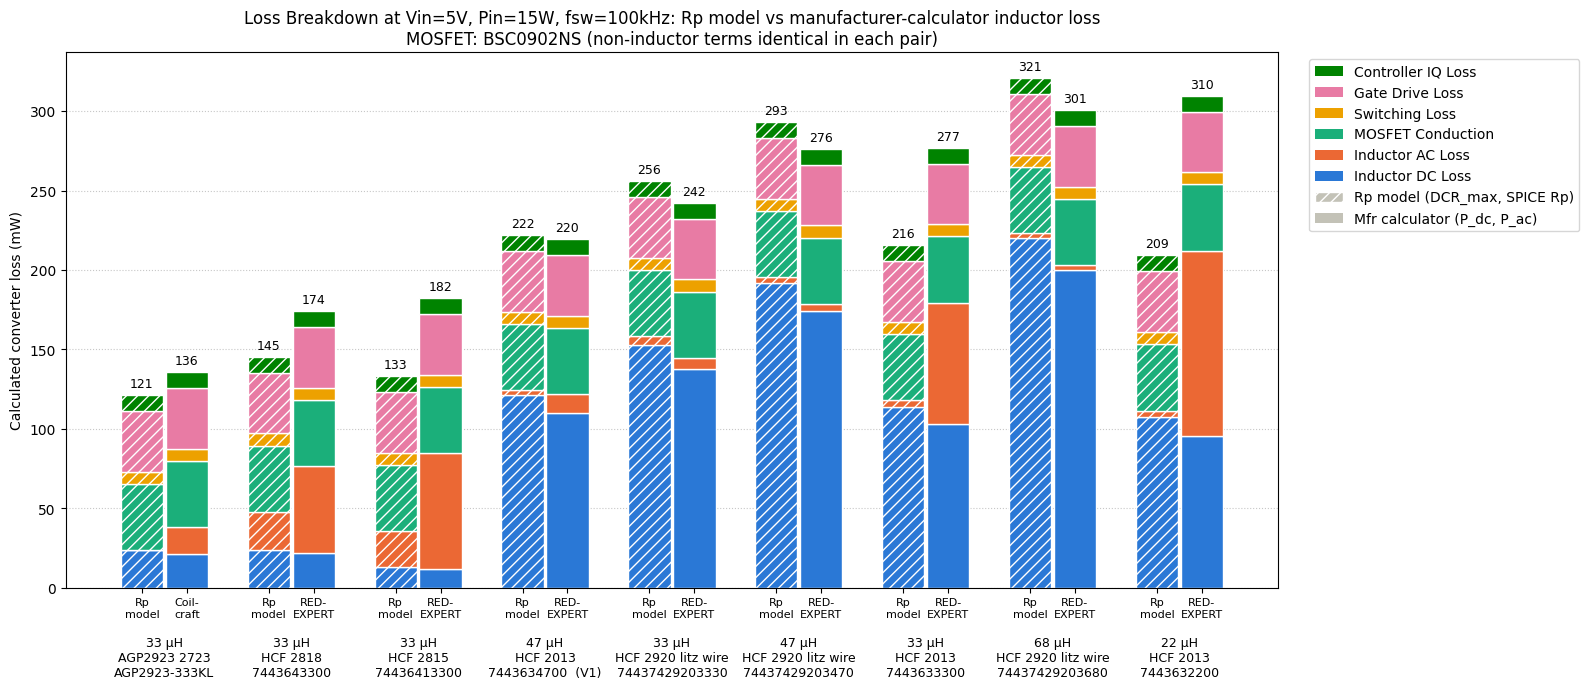

Mfr = manufacturer calculator (Tool column); Rp = SPICE-Rp model. Totals include the same calculated FET/driver/IQ terms.
AC Mfr/Rp is blank where the part has no SPICE Rp (Rp-model AC term = 0).
 Freq_kHz    Part_Number          Tool      Size_Code  L_uH  dI_pp (A)  L_AC Rp (mW)  L_AC Mfr (mW)  AC Mfr/Rp  L_DC Rp (mW)  L_DC Mfr (mW)  Total Rp (mW)  Total Mfr (mW)  P_out Mfr (W)  Eff Mfr (%)
    100.0  AGP2923-333KL Coilcraft PIF           2723  33.0      0.884           0.0           17.0        NaN          23.6           21.0          121.2           135.6         14.864        99.10
    100.0     7443643300     REDEXPERT           2818  33.0      0.884          23.8           55.0        2.3          23.9           21.6          145.4           174.2         14.826        98.84
    100.0    74436413300     REDEXPERT           2815  33.0      0.884          22.7           72.8        3.2          13.1           12.0          133.4           182.4         14.818        98.78
    100.

In [9]:
from matplotlib.patches import Patch

SERIES = ['Rp model', 'Mfr calculator']
TOOL_TICK = {'REDEXPERT': 'RED-\nEXPERT', 'Coilcraft PIF': 'Coil-\ncraft'}

rows = []
for _, r in calc_df.iterrows():
    for series, res in zip(SERIES, [rp_model_breakdown(r), calc_breakdown(r)]):
        rows.append({'Part_Number': r['Part_Number'], 'Manufacturer': r['Manufacturer'], 'Series_Name': r['Series'],
                     'Size_Code': r['Size_Code'], 'L_uH': r['Inductance_uH'], 'Freq_kHz': r['Freq_kHz'],
                     'dI_pp_A': r['dI_pp_A'], 'P_in_W': r['Vin_V'] * r['Iin_A'], 'Tool': r['Tool'],
                     'Series': series, **res})
cmp_df = pd.DataFrame(rows)
cmp_df['Total'] = cmp_df[LOSS_TERMS].sum(axis=1)
cmp_df['P_out_W'] = cmp_df['P_in_W'] - cmp_df['Total']
cmp_df['Eff_pct'] = 100 * cmp_df['P_out_W'] / cmp_df['P_in_W']

# --- Chart: paired stacked bars at the design fsw, parts ordered by calculator total ---
f_plot = f_sw / 1e3
plot_cmp = cmp_df[cmp_df['Freq_kHz'] == f_plot]
order = plot_cmp[plot_cmp['Series'] == 'Mfr calculator'].sort_values('Total')['Part_Number'].tolist()

fig, ax = plt.subplots(figsize=(16, 7))
bar_w, pitch = 0.8, 2.4
tick_x, tick_lbl = [], []
for g, pn in enumerate(order):
    for k, series in enumerate(SERIES):
        row = plot_cmp[(plot_cmp['Part_Number'] == pn) & (plot_cmp['Series'] == series)].iloc[0]
        x = g * pitch + (k - 0.5) * (bar_w + 0.05)
        bottom = 0.0
        for term in LOSS_TERMS:
            ax.bar(x, row[term] * 1e3, bar_w, bottom=bottom, color=LOSS_COLORS[term], edgecolor='white',
                   linewidth=1, hatch='///' if series == 'Rp model' else None)
            bottom += row[term] * 1e3
        ax.text(x, bottom + 3, f"{bottom:.0f}", ha='center', va='bottom', fontsize=9)
        tick_x.append(x)
        tick_lbl.append('Rp\nmodel' if series == 'Rp model' else TOOL_TICK.get(row['Tool'], row['Tool']))
    v1_tag = '  (V1)' if pn == cfg.ACTIVE_IND_ID else ''
    ax.text(g * pitch, -0.09, f"{row['L_uH']:g} µH\n{row['Series_Name']} {row['Size_Code']}\n{pn}{v1_tag}",
            transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=9)

ax.set_xticks(tick_x, tick_lbl, fontsize=8)
ax.set_ylabel("Calculated converter loss (mW)")
ax.set_title(f"Loss Breakdown at Vin={v_in_5v:.0f}V, Pin={p_in_5v:.0f}W, fsw={f_plot:.0f}kHz: "
             f"Rp model vs manufacturer-calculator inductor loss\n"
             f"MOSFET: {fet_name} (non-inductor terms identical in each pair)")
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_axisbelow(True)
handles = [Patch(facecolor=LOSS_COLORS[t], label=t) for t in reversed(LOSS_TERMS)]
handles += [Patch(facecolor='#c3c2b7', edgecolor='white', hatch='///', label='Rp model (DCR_max, SPICE Rp)'),
            Patch(facecolor='#c3c2b7', label='Mfr calculator (P_dc, P_ac)')]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('loss_breakdown_redexpert_vs_rp.png', bbox_inches='tight')
plt.show()

# --- Table view: all calculator rows ---
key = ['Freq_kHz', 'Part_Number', 'Tool', 'Size_Code', 'L_uH']
rp_t = cmp_df[cmp_df['Series'] == 'Rp model'].set_index(key)
mf_t = cmp_df[cmp_df['Series'] == 'Mfr calculator'].set_index(key)
summary_calc = pd.DataFrame({
    'dI_pp (A)': mf_t['dI_pp_A'],
    'L_AC Rp (mW)': rp_t['Inductor AC Loss'] * 1e3,
    'L_AC Mfr (mW)': mf_t['Inductor AC Loss'] * 1e3,
    'AC Mfr/Rp': (mf_t['Inductor AC Loss'] / rp_t['Inductor AC Loss']).where(rp_t['Inductor AC Loss'] > 0),
    'L_DC Rp (mW)': rp_t['Inductor DC Loss'] * 1e3,
    'L_DC Mfr (mW)': mf_t['Inductor DC Loss'] * 1e3,
    'Total Rp (mW)': rp_t['Total'] * 1e3,
    'Total Mfr (mW)': mf_t['Total'] * 1e3,
    'P_out Mfr (W)': mf_t['P_out_W'],
    'Eff Mfr (%)': mf_t['Eff_pct'],
}).reset_index().sort_values(['Freq_kHz', 'Total Mfr (mW)'])
digits = {c: 1 for c in summary_calc.columns if c.endswith('(mW)') or c == 'AC Mfr/Rp'}
digits.update({'dI_pp (A)': 3, 'P_out Mfr (W)': 3, 'Eff Mfr (%)': 2})
print("Mfr = manufacturer calculator (Tool column); Rp = SPICE-Rp model. Totals include the same calculated "
      "FET/driver/IQ terms.\nAC Mfr/Rp is blank where the part has no SPICE Rp (Rp-model AC term = 0).")
print(summary_calc.round(digits).to_string(index=False))

# --- Does the inductor ranking depend on the FET? (the FETs used by earlier versions of these cells) ---
print(f"\nRanking by manufacturer-calculator total at {f_plot:.0f} kHz, per MOSFET (mW):")
for name in [fet_name, 'BSZ0902NS', 'BSZ0501NSI']:
    fet = fet_params(name)
    tot = {r['Part_Number']: sum(calc_breakdown(r, fet).values()) * 1e3
           for _, r in calc_df[calc_df['Freq_kHz'] == f_plot].iterrows()}
    print(f"  {name:<11} " + " < ".join(f"{pn} ({tot[pn]:.0f})" for pn in sorted(tot, key=tot.get)))

# --- The other V1 criteria for the same parts: ripple window (20 V, as in the verification cell),
# peak current at the top of the PD range with full load vs datasheet I_sat (10 % drop), size, reference price ---
i_out_42w = cfg.TOTAL_MAX_LOAD_WATTS / v_out
v_in_hi = cfg.USB.V_MAX * (1 + cfg.USB.V_TOLERANCE)
crit = plot_cmp[plot_cmp['Series'] == 'Mfr calculator'][['Part_Number', 'Tool', 'Size_Code', 'L_uH', 'Total']].merge(
    ind_db[['Part_Number', 'Isat_10pct_A', 'Length_max_mm', 'Width_max_mm', 'Height_max_mm', 'Price_Ref_50_USD']],
    on='Part_Number').sort_values('Total')
crit['Total (mW)'] = crit.pop('Total') * 1e3
crit['Ripple_20V_pct'] = [100 * calculate_ripple(cfg.USB.V_MAX, v_out, L*1e-6, f_sw) / i_out_42w for L in crit['L_uH']]
crit['I_peak_A'] = [i_out_42w + calculate_ripple(v_in_hi, v_out, L*1e-6, f_sw) / 2 for L in crit['L_uH']]
crit['Isat_margin_pct'] = 100 * (crit['Isat_10pct_A'] / crit['I_peak_A'] - 1)
print(f"\nOther criteria (ripple % of {i_out_42w:.2f} A at {cfg.USB.V_MAX:.0f} V, window 20-40 %; "
      f"I_peak at {v_in_hi:.0f} V, {cfg.TOTAL_MAX_LOAD_WATTS:.1f} W out):")
print(crit.round(2).to_string(index=False))

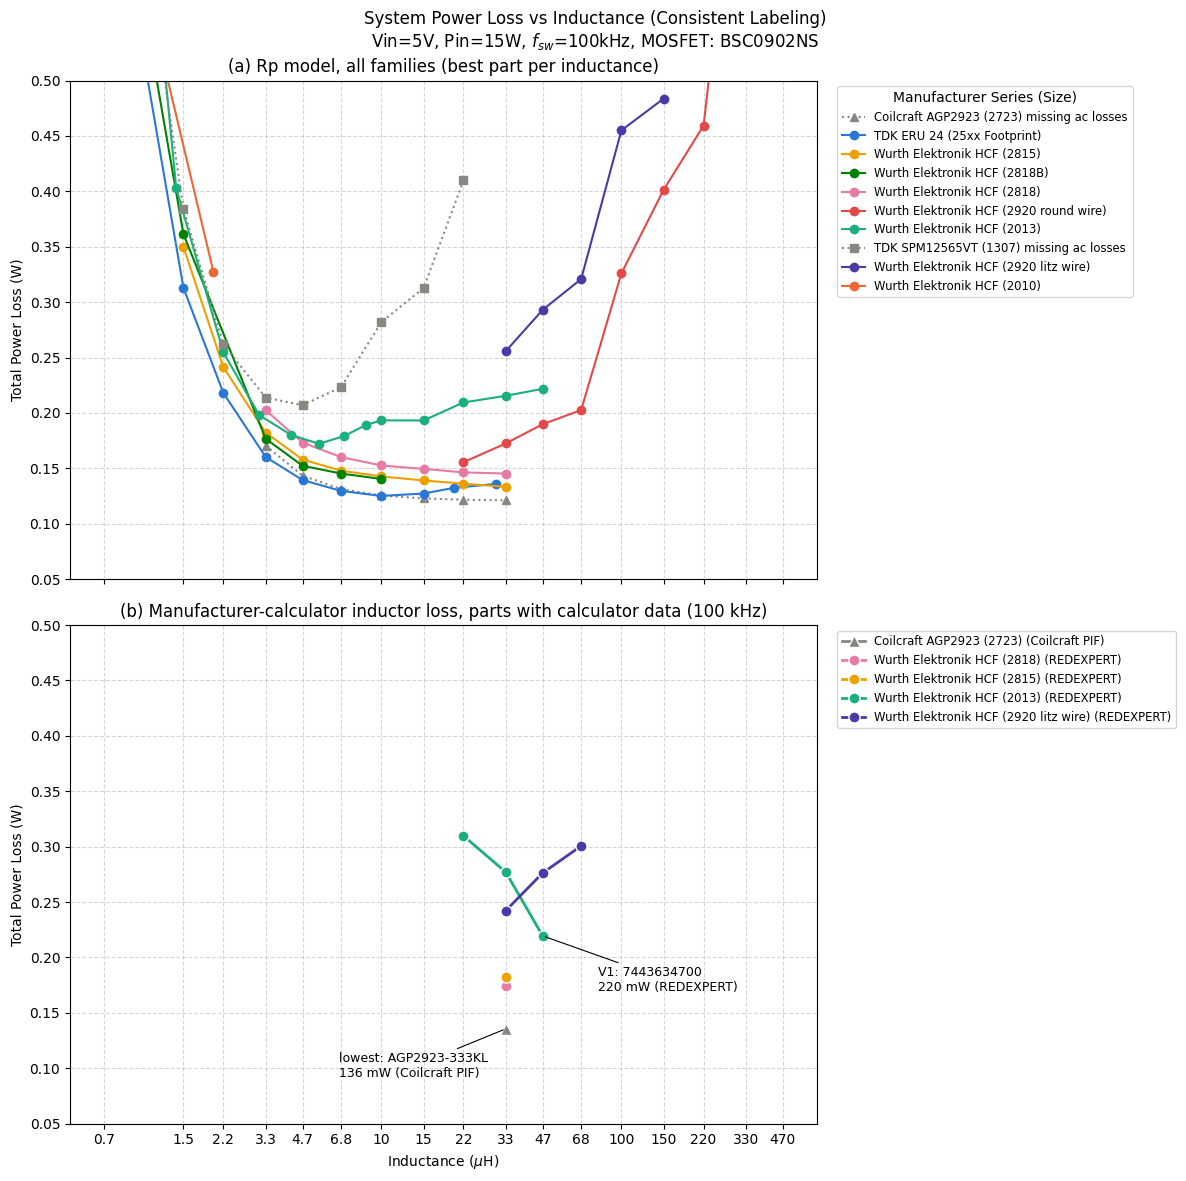

Rp model, lowest 10:
                               Group_Label     Part_Number  Inductance_uH  Total_Loss_W  Eff_pct
Coilcraft AGP2923 (2723) missing ac losses   AGP2923-333KL           33.0        0.1212    99.19
Coilcraft AGP2923 (2723) missing ac losses   AGP2923-223KL           22.0        0.1217    99.19
Coilcraft AGP2923 (2723) missing ac losses   AGP2923-153KL           15.0        0.1229    99.18
               TDK ERU 24 (25xx Footprint) B82559A9103A024           10.0        0.1251    99.17
Coilcraft AGP2923 (2723) missing ac losses   AGP2923-103KL           10.0        0.1256    99.16
               TDK ERU 24 (25xx Footprint) B82559A0153A024           15.0        0.1273    99.15
               TDK ERU 24 (25xx Footprint) B82559A7682A024            6.8        0.1297    99.14
Coilcraft AGP2923 (2723) missing ac losses   AGP2923-682KL            6.8        0.1313    99.12
               TDK ERU 24 (25xx Footprint) B82559A0203A024           20.0        0.1324    99.12
         

In [10]:
fam_df = ind_db.copy()

# Handle missing size codes and clean data
fam_df['Size_Code'] = fam_df['Size_Code'].fillna('Unknown')

# Define a "Plotting Group" label - CONSISTENT VERSION
def create_group_label(row):
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'ERU 24':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return "TDK ERU 24 (25xx Footprint)"
    if row['Manufacturer'] == 'Coilcraft' and row['Series'] == 'AGP2923':
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'SPM12565VT':
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']})"

fam_df['Group_Label'] = fam_df.apply(create_group_label, axis=1)

# Rp-model total loss for every part at the 15 W input point
fam_df['Total_Loss_W'] = fam_df.apply(lambda row: sum(boost_loss_breakdown(
    v_in_5v, i_in_5v, v_out, row['Inductance_uH']*1e-6, row['DCR_max_mOhm']*1e-3, row['Rp_Ohm'], f_sw
).values()), axis=1)

# Group and find best within each Inductance value per Family
plot_df = fam_df.loc[fam_df.groupby(['Group_Label', 'Inductance_uH'])['Total_Loss_W'].idxmin()]
plot_df = plot_df.sort_values(['Group_Label', 'Inductance_uH'])

# Color follows the family (fixed by name, not by loss rank). Families with no AC-loss term are
# muted gray: their curve is a DC-only lower bound.
SERIES_SLOTS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED = '#898781'
all_groups = sorted(plot_df['Group_Label'].unique())
no_ac_groups = [g for g in all_groups if g.endswith('missing ac losses')]
ac_groups = [g for g in all_groups if g not in no_ac_groups]
assert len(ac_groups) <= len(SERIES_SLOTS), "more families than color slots: facet or fold into 'Other'"
family_color = dict(zip(ac_groups, SERIES_SLOTS))
family_style = {g: dict(color=family_color[g], marker='o', linestyle='-') for g in ac_groups}
family_style.update({g: dict(color=MUTED, marker=m, linestyle=':') for g, m in zip(no_ac_groups, ['^', 's', 'D'])})

fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)

# (a) Rp model, all families (sorted by minimum loss, as before)
ordered_labels = plot_df.groupby('Group_Label')['Total_Loss_W'].min().sort_values().index
for label in ordered_labels:
    subset = plot_df[plot_df['Group_Label'] == label]
    ax_a.plot(subset['Inductance_uH'], subset['Total_Loss_W'], lw=1.5, ms=6, label=label, **family_style[label])
ax_a.set_title("(a) Rp model, all families (best part per inductance)")
ax_a.legend(title="Manufacturer Series (Size)", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

# (b) Manufacturer-calculator loss (same axes as (a), so the Rp-model estimate for each family sits directly above)
calc_plot = cmp_df[(cmp_df['Series'] == 'Mfr calculator') & (cmp_df['Freq_kHz'] == f_sw / 1e3)].merge(
    fam_df[['Part_Number', 'Group_Label']], on='Part_Number').sort_values('L_uH')
ordered_calc = calc_plot.groupby('Group_Label')['Total'].min().sort_values().index
for label in ordered_calc:
    sub = calc_plot[calc_plot['Group_Label'] == label]
    style = family_style[label]
    tools = '/'.join(sub['Tool'].unique())
    ax_b.plot(sub['L_uH'], sub['Total'], color=style['color'], marker=style['marker'], lw=2, ls='-', ms=8, mec='white',
              label=f"{label.replace(' missing ac losses', '')} ({tools})")
best_calc = calc_plot.nsmallest(1, 'Total').iloc[0]
v1 = calc_plot[calc_plot['Part_Number'] == cfg.ACTIVE_IND_ID].iloc[0]
for pt, txt, off in [(v1, 'V1', (40, -40)), (best_calc, 'lowest', (-120, -35))]:
    if txt == 'lowest' and pt['Part_Number'] == v1['Part_Number']:
        continue
    ax_b.annotate(f"{txt}: {pt['Part_Number']}\n{pt['Total']*1e3:.0f} mW ({pt['Tool']})", xy=(pt['L_uH'], pt['Total']),
                  xytext=off, textcoords='offset points', fontsize=9, arrowprops=dict(arrowstyle='-', lw=0.8))
ax_b.set_title(f"(b) Manufacturer-calculator inductor loss, parts with calculator data ({f_sw/1e3:.0f} kHz)")
ax_b.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

fig.suptitle(f"System Power Loss vs Inductance (Consistent Labeling)\n"
             f"Vin={v_in_5v:.0f}V, Pin={p_in_5v:.0f}W, $f_{{sw}}$={f_sw/1e3:.0f}kHz, MOSFET: {fet_name}")
for ax in (ax_a, ax_b):
    ax.set_ylabel("Total Power Loss (W)")
    ax.set_xscale('log')
    ax.set_ylim([0.05, 0.5])
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
ax_b.set_xlabel(r"Inductance ($\mu$H)")

# Ticks
unique_l = sorted(plot_df['Inductance_uH'].unique())
min_losses = plot_df.groupby('Inductance_uH')['Total_Loss_W'].min()
clusters = []
if unique_l:
    current_cluster = [unique_l[0]]
    for val in unique_l[1:]:
        if (val - current_cluster[-1]) / current_cluster[-1] < 0.20:
            current_cluster.append(val)
        else:
            clusters.append(current_cluster)
            current_cluster = [val]
    clusters.append(current_cluster)
filtered_ticks = [min(c, key=lambda x: min_losses[x]) for c in clusters]
ax_b.set_xticks(filtered_ticks, [f"{t:g}" for t in filtered_ticks])
ax_b.minorticks_off()

plt.tight_layout()
plt.savefig('loss_by_family_consistent.png', bbox_inches='tight')
plt.show()

# Summary (Rp model)
plot_df['Eff_pct'] = 100 * (1 - plot_df['Total_Loss_W'] / p_in_5v)
summary = plot_df.sort_values('Total_Loss_W').head(10)[['Group_Label', 'Part_Number', 'Inductance_uH', 'Total_Loss_W', 'Eff_pct']]
print("Rp model, lowest 10:")
print(summary.round({'Total_Loss_W': 4, 'Eff_pct': 2}).to_string(index=False))

# --- AC-loss budget for parts without calculator data ---
# A part beats a reference only if P_dc + P_ac + (non-inductor terms) is lower than the reference total.
# P_dc uses the calculators' split, I_L,avg^2 x typical DCR (DCR_max where no typical is listed), so the
# budget is the P_ac (core + ripple winding loss) the part could have and still win.
# References: the V1 part, and the lowest-loss part with calculator data.
# Candidates are limited to L >= the smallest inductance with calculator data (22 µH); lower values
# are far outside the 20-40 % ripple window checked above. Ripple columns are printed for reference.
cand = fam_df[~fam_df['Part_Number'].isin(calc_df['Part_Number'])
              & (fam_df['Inductance_uH'] >= calc_df['Inductance_uH'].min())].copy()
cand['DCR_used_mOhm'] = cand['DCR_typ_mOhm'].fillna(cand['DCR_max_mOhm'])
cand['P_dc_mW'] = i_in_5v**2 * cand['DCR_used_mOhm']
cand['Non_ind_mW'] = cand.apply(lambda row: sum(boost_loss_breakdown(
    v_in_5v, i_in_5v, v_out, row['Inductance_uH']*1e-6, 0.0, None, f_sw).values()) * 1e3, axis=1)
cand['AC_budget_vs_V1_mW'] = v1['Total'] * 1e3 - cand['P_dc_mW'] - cand['Non_ind_mW']
cand['AC_budget_vs_best_mW'] = best_calc['Total'] * 1e3 - cand['P_dc_mW'] - cand['Non_ind_mW']
cand['dI_pp_5V_A'] = [calculate_ripple(v_in_5v, v_out, L*1e-6, f_sw) for L in cand['Inductance_uH']]
cand['Ripple_20V_pct'] = [100 * calculate_ripple(cfg.USB.V_MAX, v_out, L*1e-6, f_sw) / (cfg.TOTAL_MAX_LOAD_WATTS / v_out)
                          for L in cand['Inductance_uH']]
best_per_family = cand.loc[cand.groupby('Group_Label')['AC_budget_vs_V1_mW'].idxmax()].sort_values(
    'AC_budget_vs_V1_mW', ascending=False)
print(f"\nAC-loss budget for parts without calculator data, best part per family, L >= {calc_df['Inductance_uH'].min():g} µH."
      f"\nReferences: V1 {v1['Part_Number']} = {v1['Total']*1e3:.1f} mW; lowest with calculator data "
      f"{best_calc['Part_Number']} = {best_calc['Total']*1e3:.1f} mW. Negative = loses even with zero AC loss.")
print(best_per_family[['Group_Label', 'Part_Number', 'Inductance_uH', 'DCR_used_mOhm', 'P_dc_mW', 'Non_ind_mW',
                       'AC_budget_vs_V1_mW', 'AC_budget_vs_best_mW', 'dI_pp_5V_A', 'Ripple_20V_pct']]
      .round(1).to_string(index=False))

## V1 choice under the JLCPCB stock constraint

V1 was built through JLCPCB assembly, so a part JLCPCB does not stock costs more and adds sourcing risk. Hand check on JLCPCB, 2026-09-14: of the nine parts with manufacturer-calculator data, only `7443634700` is stocked ($6.70, recorded as `Price_Build_USD`). The three lower-loss 33 µH parts (`AGP2923-333KL`, `7443643300`, `74436413300`) are not stocked, and JLCPCB's price for them is above $10 each. Following `data/README.md`, no build price is recorded for parts LCSC does not stock, so that $10 floor appears only in the cell below.

The cell quantifies what the lower-loss parts would buy at the 5 V / 3 A input point:
- **Fan power:** at the source limit the input stays 15 W either way, so lower loss means more output power, not longer run time.
- **Run time:** below the source limit, the fans draw a fixed output power and input power = P_out / η, so battery run time scales with η.
- **Electricity:** a generous ceiling. It applies the 15 W-input loss saving for every hour of the year, even though the README mission profile spends 95 % of the time at 1.5 W, where the DC-loss difference is roughly 1 % as large (current about 10× lower). Loss at the mission-profile operating points has not been calculated (notebook 09).

In [11]:
# JLCPCB price floor for the unstocked 33 µH parts (hand check 2026-09-14; not recordable as Price_Build_USD)
jlcpcb_unstocked_min_usd = 10.0

v1_part = ind_db[ind_db['Part_Number'] == cfg.ACTIVE_IND_ID].iloc[0]
v1_loss_mw = crit.loc[crit['Part_Number'] == cfg.ACTIVE_IND_ID, 'Total (mW)'].iloc[0]
v1_eff = 100 * (1 - v1_loss_mw / 1e3 / p_in_5v)

choice = crit[crit['Total (mW)'] <= v1_loss_mw].copy()        # V1 part + every part with lower calculated loss
choice['Eff_15W_pct'] = 100 * (1 - choice['Total (mW)'] / 1e3 / p_in_5v)
choice['P_out_W'] = p_in_5v - choice['Total (mW)'] / 1e3
choice['Saving_mW'] = v1_loss_mw - choice['Total (mW)']
choice['Runtime_gain_s_per_h'] = 3600 * (choice['Eff_15W_pct'] / v1_eff - 1)
choice['Elec_ceiling_USD_per_yr'] = choice['Saving_mW'] / 1e6 * cfg.HOURS_PER_YEAR * cfg.ELECTRICITY_USD_PER_KWH
choice['JLCPCB_USD'] = np.where(choice['Part_Number'] == cfg.ACTIVE_IND_ID, v1_part['Price_Build_USD'], np.nan)
choice['Payback_min_yr'] = np.where(choice['Saving_mW'] > 0,
                                    (jlcpcb_unstocked_min_usd - v1_part['Price_Build_USD']) / choice['Elec_ceiling_USD_per_yr'],
                                    np.nan)
choice['Body_area_mm2'] = choice['Length_max_mm'] * choice['Width_max_mm']

print(f"Vin = {v_in_5v:.0f} V, Pin = {p_in_5v:.0f} W, {f_sw/1e3:.0f} kHz, MOSFET {fet_name}. "
      f"JLCPCB: {cfg.ACTIVE_IND_ID} stocked at ${v1_part['Price_Build_USD']:.2f}; others not stocked, > ${jlcpcb_unstocked_min_usd:.0f}.")
print(f"Electricity ceiling: saving applied {cfg.HOURS_PER_YEAR} h/yr at ${cfg.ELECTRICITY_USD_PER_KWH:.2f}/kWh. "
      f"Payback = (${jlcpcb_unstocked_min_usd:.0f} - V1 build price) / ceiling, so a lower bound.\n")
cols = ['Part_Number', 'Size_Code', 'L_uH', 'Total (mW)', 'Eff_15W_pct', 'P_out_W', 'Saving_mW', 'Runtime_gain_s_per_h',
        'Elec_ceiling_USD_per_yr', 'JLCPCB_USD', 'Payback_min_yr', 'Body_area_mm2', 'Height_max_mm']
print(choice[cols].round({'Total (mW)': 1, 'Eff_15W_pct': 2, 'P_out_W': 3, 'Saving_mW': 1, 'Runtime_gain_s_per_h': 1,
                          'Elec_ceiling_USD_per_yr': 3, 'JLCPCB_USD': 2, 'Payback_min_yr': 0, 'Body_area_mm2': 0})
      .to_string(index=False))

Vin = 5 V, Pin = 15 W, 100 kHz, MOSFET BSC0902NS. JLCPCB: 7443634700 stocked at $6.70; others not stocked, > $10.
Electricity ceiling: saving applied 8760 h/yr at $0.20/kWh. Payback = ($10 - V1 build price) / ceiling, so a lower bound.

  Part_Number Size_Code  L_uH  Total (mW)  Eff_15W_pct  P_out_W  Saving_mW  Runtime_gain_s_per_h  Elec_ceiling_USD_per_yr  JLCPCB_USD  Payback_min_yr  Body_area_mm2  Height_max_mm
AGP2923-333KL      2723  33.0       135.6        99.10   14.864       83.9                  20.4                    0.147         NaN            22.0          465.0          23.75
   7443643300      2818  33.0       174.2        98.84   14.826       45.3                  11.0                    0.079         NaN            42.0          756.0          18.50
  74436413300      2815  33.0       182.4        98.78   14.818       37.1                   9.0                    0.065         NaN            51.0          756.0          15.40
   7443634700      2013  47.0       219.5  

# Final Conclusions

**Status of the choice — `7443634700` is the lowest-loss part JLCPCB stocks among those with manufacturer loss data.** Three 33 µH parts have lower calculated loss at the 5 V / 3 A point, but none is stocked at JLCPCB (hand check 2026-09-14), and what they would buy is small. Of the four, it is the only one inside the 20–40 % ripple window at 20 V, and it has the smallest body.

- **Efficiency at 15 W input (objective 1)**, manufacturer-calculator inductor loss, 100 kHz, V1 FET BSC0902NS:

  | Part | Tool | Total loss | η (calc.) | P_out | JLCPCB | Ripple @ 20 V | I_sat margin | Body |
  |---|---|---|---|---|---|---|---|---|
  | **`7443634700` 47 µH, HCF 2013 (V1)** | REDEXPERT | 219.5 mW | **98.54 %** | 14.780 W | stocked, $6.70 | 28.7 % | 81 % | 426 mm², 13.5 mm |
  | `74436413300` 33 µH, HCF 2815 | REDEXPERT | 182.4 mW | 98.78 % | 14.818 W | not stocked, > $10 | 40.8 % | 2.6 % | 756 mm², 15.4 mm |
  | `7443643300` 33 µH, HCF 2818 | REDEXPERT | 174.2 mW | 98.84 % | 14.826 W | not stocked, > $10 | 40.8 % | 139 % | 756 mm², 18.5 mm |
  | `AGP2923-333KL` 33 µH, Coilcraft | Coilcraft PIF | 135.6 mW | 99.10 % | 14.864 W | not stocked, > $10 | 40.8 % | 71 % | 465 mm², 23.75 mm, through-hole |

  The order is unchanged with BSZ0902NS or BSZ0501NSI. These totals are calculated and omit the sense resistor, capacitor ESR, dead-time conduction and PCB copper, so they rank inductors; they do not predict measured board efficiency.
- **What the lower-loss parts would buy** (calculated in *V1 choice under the JLCPCB stock constraint*):
  - **Fan power:** 37–84 mW more at the source limit (+0.25 to +0.57 %).
  - **Run time:** +9 to +20 s per hour of battery run time at a fixed load near 15 W in.
  - **Electricity:** at most $0.07–0.15 per year, a generous ceiling that applies the full 15 W-input saving all year.
  - **Payback:** against a JLCPCB price at least $3.30 higher, at least 22–51 years.

  The V1 part also uses the least board area: 330 mm² less than the 2815/2818 parts, and 39 mm² less than AGP2923-333KL at under 60 % of its height.
- **Why the saving is real, and why it is still not a drop-in improvement:**
  - The saving is mostly DC loss from datasheet DCR (e.g. AGP2923-333KL P_dc 21 vs 110 mW), so it does not hinge on either calculator. The V1 part would only draw level with AGP2923-333KL if that part's true AC loss were ≈101 mW, 6× Coilcraft's 17 mW.
  - All 33 µH parts give 40.8 % ripple at 20 V, just outside the 20–40 % window used in the verification above. `74436413300` has only 2.6 % I_sat margin (4.5 A at 10 % drop vs a 4.39 A peak at 22 V / 42.7 W).
  - `AGP2923-333KL` is through-hole (slotted terminals plus four mounting pins; Coilcraft Doc 932-1/932-2), where the Würth WE-HCF parts (V1 and the 2815/2818 candidates) are SMT. The datasheet copy in `datasheets/inductors/` (rev. 09/30/24) is marked "preproduction products for electrical evaluation only"; its current status has not been confirmed. Its reference price is $5.96 at 50 pc (Mouser) vs $6.45 for the V1 part (DigiKey), but JLCPCB is the build route.
  - Notebooks 05–08 hard-code L = 47 µH (ripple, capacitor sizing, slope compensation, the input-filter simulations), so any inductor change needs those checks repeated.
- **The Rp model does not predict AC loss.** On the same parts, calculator AC loss is 18–27× the Rp estimate for the 22/33 µH HCF 2013 parts, 2.3–3.9× for the 2818, 2815 and 47 µH 2013 parts, and 1.0–1.3× for the litz parts; `AGP2923-333KL` has no SPICE Rp at all. The Rp model put the 22 µH and 33 µH 2013 parts ahead of the V1 part, which the calculators reverse. It also ranked `AGP2923-333KL` first with no AC term at all; that part stays first with Coilcraft's figure, but the Rp ranking had no evidence behind it. Calculator P_dc is I_L,avg² × typical DCR for both tools; the Rp model uses I_L,rms² × DCR_max (≈10 % higher).
- **Switching frequency:** of the 2013 parts run at 100/150/200/300 kHz, the 47 µH part is lowest at 100 kHz (219.5 → 303.2 mW at 300 kHz). Its inductor loss drops only 122 → 114 mW while the calculated gate-drive and switching losses rise faster. Only 100 kHz data exists for the other parts.
- **Parts still without calculator data:** at this operating point, any 22–47 µH inductor must keep P_dc + P_ac below about 38 mW to beat `AGP2923-333KL` (the non-inductor terms are ≈98 mW), and below about 122 mW to beat the V1 part. The budget table applies this to the database. To beat the V1 part, TDK ERU 24 `B82559A0303A024` (30 µH, not in TDK's calculator) would need P_ac below 89 mW, and the 2920 round-wire 22 µH part below 73 mW (at 61 % ripple at 20 V). At L ≥ 22 µH, `SPM12565VT-220M-D` and the 2920 litz-wire parts ≥ 100 µH cannot beat it even with zero AC loss. JLCPCB stock has not been checked for these parts.
- **V2 candidates:** if the build route allows unstocked or through-hole parts, `7443643300` (best SMT, 98.84 %) and `AGP2923-333KL` (99.10 %). Deciding needs JLCPCB/LCSC availability at build time, AGP2923's current production status, and repeats of notebooks 05–08 at 33 µH. On operating cost the saving is worth cents per year, so objective 2 does not favor them.
- **Cost (objective 2):** not a selection criterion in V1. At the 50 pc reference quantity `7443634700` is $6.45, vs $2.778 for `SPM12565VT-220M-D` and $5.96 for `AGP2923-333KL`. The cost-inclusive comparison is deferred to notebook 09.

In [12]:
r_t = (1 / f_sw-190e-9) / 116e-12 # LM5176 datasheet
inductor_choice = "47 uH, Wurth 7443634700"